In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, label_binarize
from sklearn.svm import SVC, SVR
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.cluster import KMeans
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,  matthews_corrcoef, confusion_matrix, r2_score,  mean_squared_error, mean_absolute_error, roc_curve,  auc, roc_auc_score)
from xgboost import XGBClassifier
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.decomposition import PCA
from scipy import stats


In [ ]:
df=pd.read_csv('cardio_train.csv',sep=";")
df

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62.0,110,80,1,1,0,0,1,0
1,1,20228,1,156,85.0,140,90,3,1,0,0,1,1
2,2,18857,1,165,64.0,130,70,3,1,0,0,0,1
3,3,17623,2,169,82.0,150,100,1,1,0,0,1,1
4,4,17474,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,19240,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,22601,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,19066,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,22431,1,163,72.0,135,80,1,2,0,0,0,1


In [ ]:
df['age']=(df['age']/365.25).round()
df


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,50.0,2,168,62.0,110,80,1,1,0,0,1,0
1,1,55.0,1,156,85.0,140,90,3,1,0,0,1,1
2,2,52.0,1,165,64.0,130,70,3,1,0,0,0,1
3,3,48.0,2,169,82.0,150,100,1,1,0,0,1,1
4,4,48.0,1,156,56.0,100,60,1,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
69995,99993,53.0,2,168,76.0,120,80,1,1,1,0,1,0
69996,99995,62.0,1,158,126.0,140,90,2,2,0,0,1,1
69997,99996,52.0,2,183,105.0,180,90,3,1,0,1,0,1
69998,99998,61.0,1,163,72.0,135,80,1,2,0,0,0,1


In [ ]:
if 'id' in df.columns:
    df.drop(columns=['id'], inplace=True)

In [ ]:
df['bmi'] = df['weight'] / ((df['height']/100)**2)
df = df[(df['bmi'] >= 15) & (df['bmi'] <= 50)]

In [ ]:
df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
df['hypertension'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)
df['obesity'] = (df['bmi'] >= 30).astype(int)

df = df.drop(columns=['height', 'weight', 'ap_hi', 'ap_lo'])


<ipython-input-7-d805715d4f7b>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['pulse_pressure'] = df['ap_hi'] - df['ap_lo']
<ipython-input-7-d805715d4f7b>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['hypertension'] = ((df['ap_hi'] >= 140) | (df['ap_lo'] >= 90)).astype(int)
<ipython-input-7-d805715d4f7b>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: http

In [ ]:
X = df.drop('cardio', axis=1)
y = df['cardio']
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

## logistic reg.

In [ ]:
# split data 9:10 as it is best
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

model = LogisticRegression(solver='liblinear')
model.fit(X_train, y_train)
predictions = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, predictions)
print(f"Accuracy of LR model: {accuracy * 100:.2f}%")

Accuracy of LR model: 72.87%


In [114]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

logreg = LogisticRegression(max_iter=1000, random_state=42)
logreg.fit(X_train, y_train)


LogisticRegression(max_iter=1000, random_state=42)

In [115]:
y_prob = logreg.predict_proba(X_test)[:, 1]

# binarize labels to make sure if not binary
y_test_bin = label_binarize(y_test, classes=[0, 1]).ravel()


In [116]:
# calc. ROC and AUC
fpr, tpr, _ = roc_curve(y_test_bin, y_prob)
roc_auc = roc_auc_score(y_test_bin, y_prob)


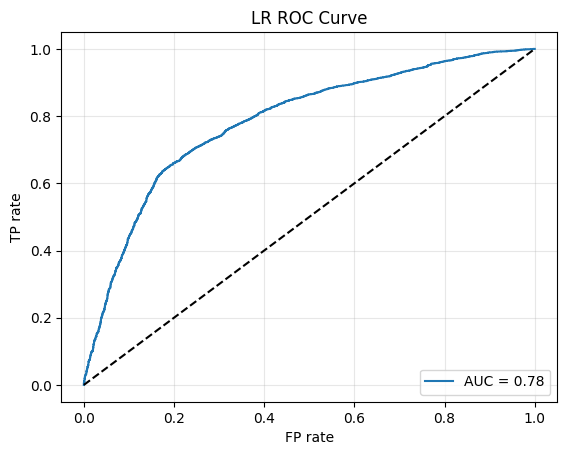

In [117]:
#ROC curve
plt.figure()
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0, 1], [0, 1], 'k--') #DASH LINE
plt.title("LR ROC Curve")
plt.xlabel("FP rate")
plt.ylabel("TP rate")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [120]:
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
print(recall,f1,r2,mse)

0.6512022630834512 0.7086347545020779 -0.08611294188506347 0.27147569195468235


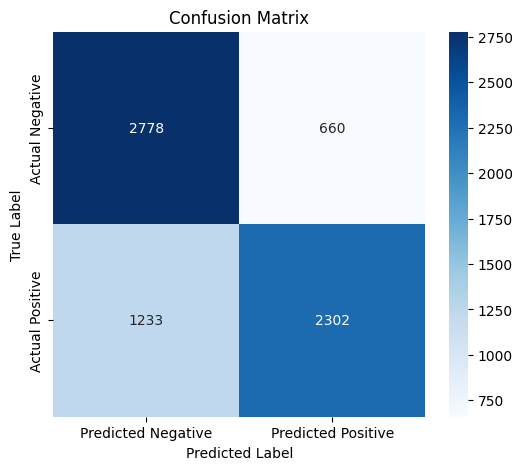

In [121]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Negative', 'Predicted Positive'],
            yticklabels=['Actual Negative', 'Actual Positive'])

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

In [ ]:
!pip install lime
!pip install shap

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 5.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for lime: filename=lime-0.2.0.1-py3-none-any.whl size=283834 sha256=9ecf476cc3b76d7262fe67f4235b7ca6d5a0f02e9bc7126b9ead54bdea907f2c
  Stored in directory: /root/.cache/pip/wheels/85/fa/a3/9c2d44c9f3cd77cf4e533b58900b2bf4487f2a17e8ec212a3d
Successfully built lime


In [72]:
import shap

explainer = shap.LinearExplainer(
    model,
    X_train,
    feature_perturbation="interventional"
)


/usr/local/lib/python3.11/dist-packages/shap/explainers/_linear.py:99: FutureWarning: The feature_perturbation option is now deprecated in favor of using the appropriate masker (maskers.Independent, maskers.Partition or maskers.Impute).
  warnings.warn(wmsg, FutureWarning)


In [73]:
shap_values = explainer.shap_values(X_test)

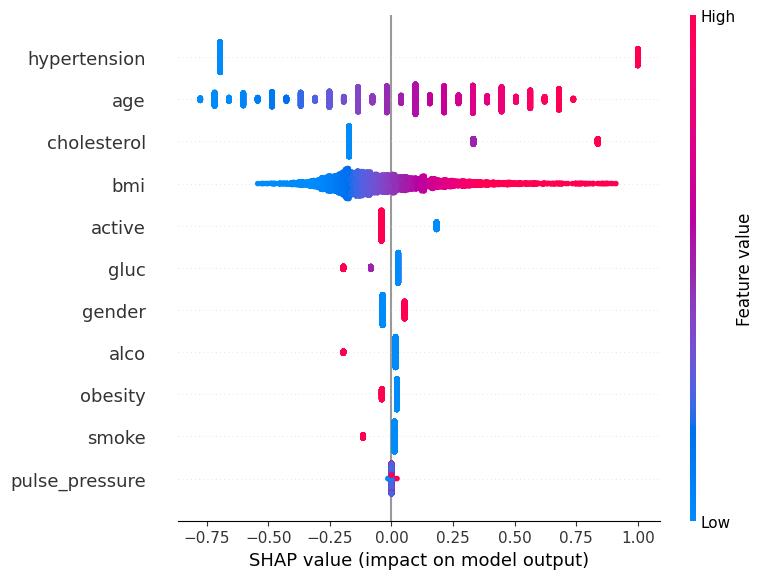

In [79]:
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values,
    X_test,
    feature_names=X.columns,
    show=False
)


In [80]:
import lime
feature_names = X.columns.tolist()
class_names = ['age', 'ap_hi']


In [82]:
explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=X_train.values,
    mode="classification",
    feature_names=feature_names,
    class_names=class_names,
    discretize_continuous=True,
    random_state=42
)

In [83]:

instance_idx = 0
instance = X_test.iloc[instance_idx].values



In [84]:
exp = explainer.explain_instance(
    data_row=instance,
    predict_fn=model.predict_proba,
    num_features=5,
    top_labels=1
)

exp.show_in_notebook(show_table=True, show_all=False)

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


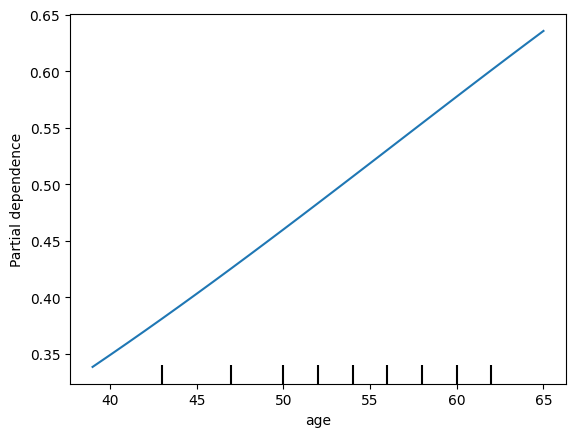

In [85]:
from sklearn.inspection import PartialDependenceDisplay

feature = [0]

target_class = 0

PartialDependenceDisplay.from_estimator(model, X_test, features=feature, target=target_class)
plt.show()

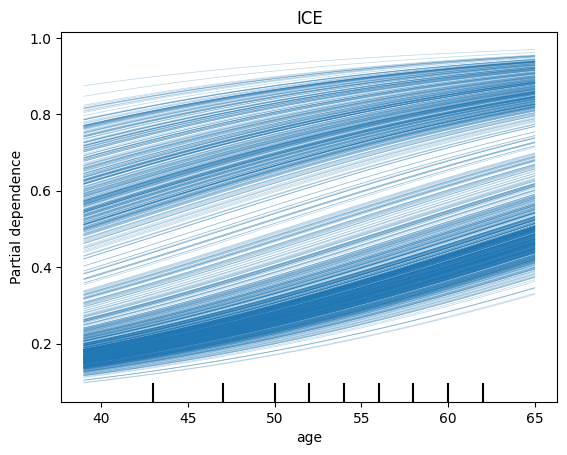

In [86]:
PartialDependenceDisplay.from_estimator(model, X_test, features=feature, target=target_class, kind='individual')
plt.title("ICE" )
plt.show()

In [87]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)



In [91]:
feature_names = X.columns

sorted_idx = result.importances_mean.argsort()
print(feature_names)
sorted_idx

Index(['age', 'gender', 'cholesterol', 'gluc', 'smoke', 'alco', 'active',
       'bmi', 'pulse_pressure', 'hypertension', 'obesity'],
      dtype='object')


array([10,  4,  8,  6,  5,  3,  1,  7,  0,  2,  9])

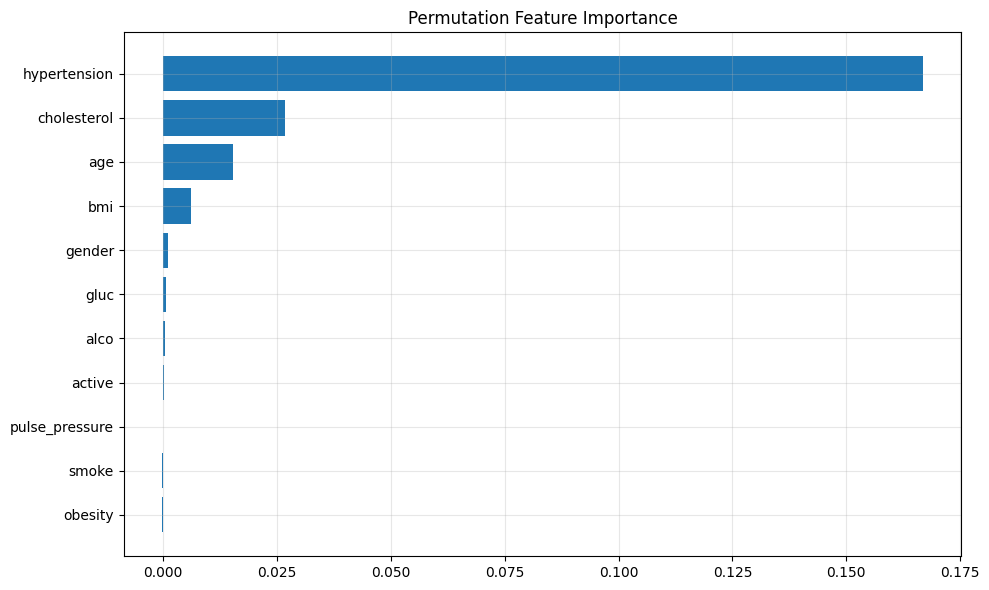

In [95]:
plt.figure(figsize=(10, 6))
plt.barh(feature_names[sorted_idx], result.importances_mean[sorted_idx])
plt.title("Permutation Feature Importance")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [93]:

from sklearn.model_selection import cross_val_score


X_train_df = pd.DataFrame(X_train, columns=X.columns)

lofo_scores = {}

baseline_score = cross_val_score(
    model,
    X_train_df,
    y_train,
    cv=5,
    scoring='accuracy'
).mean()


In [94]:

for col in X_train_df.columns:
    X_lofo = X_train_df.drop(columns=[col])
    score = cross_val_score(
        model,
        X_lofo,
        y_train,
        cv=5,
        scoring='accuracy'
    ).mean()
    lofo_scores[col] = baseline_score - score


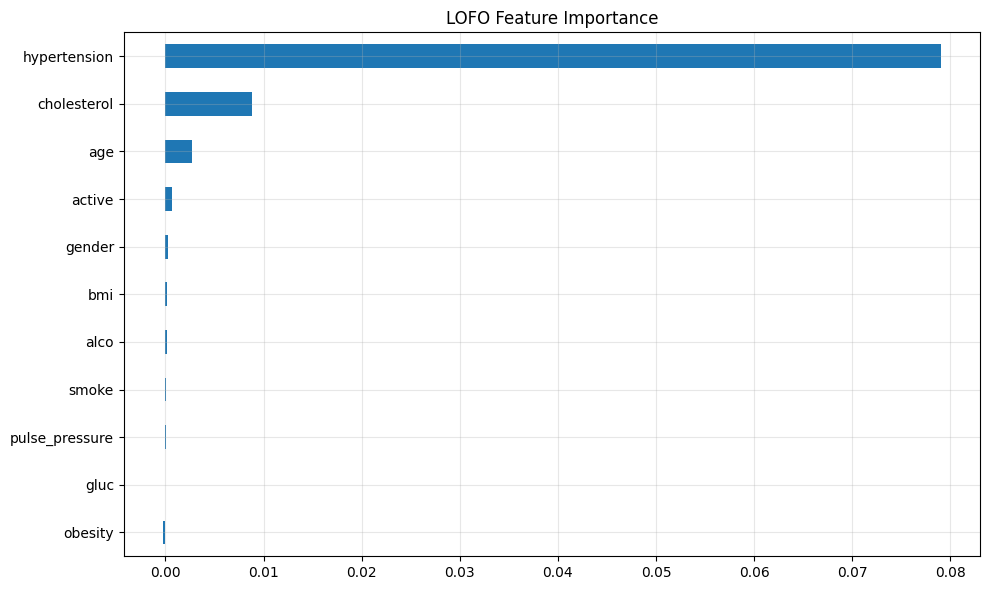

In [96]:
sorted_scores = pd.Series(lofo_scores).sort_values(ascending=True)

plt.figure(figsize=(10, 6))
sorted_scores.plot(kind='barh')
plt.title('LOFO Feature Importance')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()